In [28]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import numpy
from keras.datasets import imdb
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout, Conv1D, MaxPooling1D, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.utils import pad_sequences

numpy.random.seed(7)

In [29]:
top_words = 5000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=top_words)

In [30]:
max_review_length = 200
X_train = pad_sequences(X_train, maxlen=max_review_length)
X_test = pad_sequences(X_test, maxlen=max_review_length)

In [31]:
embedding_vecor_length = 32
model = Sequential()
model.add(Embedding(top_words, embedding_vecor_length, input_length=max_review_length))
model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(100, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
              metrics=['accuracy'])
print(model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [32]:
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=8, batch_size=64,
                    callbacks=[es])

Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.6981 - loss: 0.5454 - val_accuracy: 0.8438 - val_loss: 0.3606
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 411s 1s/step - accuracy: 0.8656 - loss: 0.3244 - val_accuracy: 0.8755 - val_loss: 0.2923
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.8974 - loss: 0.2659 - val_accuracy: 0.8788 - val_loss: 0.2872
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 410s 1s/step - accuracy: 0.9069 - loss: 0.2397 - val_accuracy: 0.8792 - val_loss: 0.2871
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 462s 1s/step - accuracy: 0.9161 - loss: 0.2200 - val_accuracy: 0.8752 - val_loss: 0.2994
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 409s 1s/step - accuracy: 0.9252 - loss: 0.2014 - val_accuracy: 0.8757 - val_loss: 0.3258


In [33]:
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1] * 100))

Accuracy: 87.92%


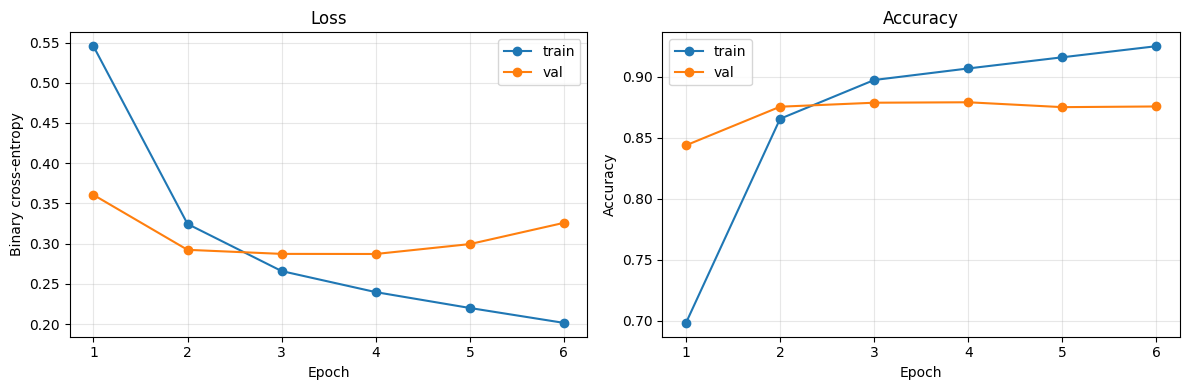

In [34]:
import matplotlib.pyplot as plt

h = history.history
epochs_range = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, h['loss'], 'o-', label='train')
axes[0].plot(epochs_range, h['val_loss'], 'o-', label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary cross-entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, h['accuracy'], 'o-', label='train')
axes[1].plot(epochs_range, h['val_accuracy'], 'o-', label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()